# Enseñar a usar herramientas: fine-tuning con trayectorias

### Sesión 10 · Módulo 3 — LoRA sobre trayectorias de tool calling · C5-FT (2/4)

**Proyecto:** Tutor inteligente de matemáticas · Comparación de arquitecturas
mediante fine-tuning
**Curso:** SI4006 · Tópicos Especiales y Aplicaciones en IA · Universidad EAFIT
**Notebook base:** `S04_Lab_Fine_tuning_Qwen.ipynb`

---

## 1 · Introducción

El notebook 1 dejó 199 trayectorias validadas. Este las usa para **entrenar** un
adaptador que aprenda **cuándo** llamar una herramienta, **cuál** y **con qué
argumentos**. El notebook 3 lo compara con la alternativa sin entrenamiento
(few-shot):

> **C5** (tool calling nativo + few-shot) **vs. C5-FT** (lo mismo + este adaptador)
> — la diferencia responde con datos *¿basta con mostrar ejemplos o hay que entrenar?*

### Decisiones de diseño

| Decisión | Elección | Por qué |
|---|---|---|
| Punto de partida | **Qwen2.5-1.5B base**, no la LoRA de M1 | La LoRA de M1 aprendió a responder *siempre* con "Paso 1:", lo que compite con emitir `<tool_call>`. Las trayectorias ya terminan con ese formato, así que el adaptador nuevo aprende las dos cosas. |
| Qué se entrena | **Solo los turnos del asistente** (pensamiento + llamada + respuesta final) | Las observaciones las escribe la herramienta y la pregunta el usuario; aprender a *predecirlas* sería aprender a inventar resultados, justo lo contrario del objetivo. |
| Formato | La plantilla nativa de Qwen2.5 con **los mismos esquemas y el mismo prompt de sistema de C5** | Lo que se entrena debe ser idéntico a lo que se evalúa. |
| LoRA | r=16, α=32, atención + MLP | Igual que M1 en atención; se añade MLP porque aquí se aprende un comportamiento nuevo (decidir y formatear llamadas), no solo un estilo. |
| Validación | 42 trayectorias **de validación**, nunca los eval sets | Los eval sets se reservan para el notebook 3. |

## 2 · Objetivos

1. Tokenizar las trayectorias con **máscara de pérdida** solo sobre el asistente.
2. Entrenar el adaptador `qwen-lora-agente`.
3. Medir sobre validación, antes y después, las cuatro decisiones del agente:
   **usar o no** herramienta, **cuál**, **llamada válida**, **resultado correcto**.
4. Medir de punta a punta con el bucle real del agente.

## 0 · Preparación del entorno

> **Activen la GPU (T4).** Cada ejemplo lleva los esquemas de 16 herramientas en el
> prompt: **~2.700 tokens** antes de la primera palabra del estudiante (medido). Por
> eso se entrena con lote 1, acumulación de gradiente y *gradient checkpointing*. Ese
> mismo coste lo paga el agente en **cada paso** de inferencia, y el notebook 3 lo
> reporta como tokens por pregunta.

In [1]:
%pip install -q "transformers>=4.44" "peft>=0.12" "accelerate>=0.33" datasets sympy wandb
%pip uninstall -y -q torchao
print("Librerías instaladas. Si Colab pide reiniciar la sesión, reinícienla y sigan desde aquí.")

Librerías instaladas. Si Colab pide reiniciar la sesión, reinícienla y sigan desde aquí.


In [2]:
import os, random
import numpy as np
import torch
import transformers

SEMILLA = 42
random.seed(SEMILLA); np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
transformers.set_seed(SEMILLA)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"transformers {transformers.__version__} | torch {torch.__version__} | {DEVICE}")

transformers 5.16.1 | torch 2.11.0+cu128 | cuda


### Persistencia entre notebooks

Los notebooks 3 y 5 **leen carpetas que producen los notebooks 1, 2 y 4**:

```
1 · Qwen    -> adaptadores/qwen-lora/      ─┐
2 · BERT    -> modelos/bert-clasificador/  ─┤-> el notebook 3 las lee
4 · FLAN-T5 -> adaptadores/flan-t5-lora/    │
1,2,3,4     -> resultados/*.json           ─┴-> el notebook 5 los lee
```

En Colab, `/content` se borra al desconectar el runtime, así que ese trabajo se
perdería entre sesiones. Montando Google Drive y trabajando desde una carpeta
suya, los artefactos sobreviven y cada notebook se puede ejecutar el día que se
pueda.

Con `USAR_DRIVE = False` todo queda en `/content`, lo cual es válido si
ejecutan los notebooks 1, 2 y 3 seguidos sin desconectar.

Fuera de Colab la celda no hace nada: el directorio de trabajo se queda como
está.

> **Los checkpoints intermedios nunca van a Drive.** El `Trainer` guarda en
> `output_dir` el modelo *más el estado del optimizador* en cada época. Para el
> notebook 2, que hace fine-tuning completo de BETO, eso son varios GB que
> además se escribirían por red. Como son desechables —lo que importa es el
> modelo final—, se mandan siempre al disco local del runtime mediante
> `DIR_CHECKPOINTS`.

In [3]:
import os
from pathlib import Path

USAR_DRIVE    = True
CARPETA_DRIVE = "/content/drive/MyDrive/ProyectoIA"

try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if EN_COLAB and USAR_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    Path(CARPETA_DRIVE).mkdir(parents=True, exist_ok=True)
    os.chdir(CARPETA_DRIVE)

# Checkpoints del Trainer: grandes y desechables -> siempre en disco local.
DIR_CHECKPOINTS = "/content/salidas" if EN_COLAB else "salidas"

print(f"En Colab           : {EN_COLAB}")
print(f"Directorio de trabajo: {Path.cwd()}")
print(f"Checkpoints en     : {DIR_CHECKPOINTS}")

Mounted at /content/drive
En Colab           : True
Directorio de trabajo: /content/drive/MyDrive/ProyectoIA
Checkpoints en     : /content/salidas


---
## 3 · El núcleo (copia literal de `scripts/agente/`)

In [4]:
"""
Tool Registry: herramientas tipadas, con esquema generado y ejecución segura.

Decisión de diseño: el esquema JSON de cada herramienta NO se escribe a mano.
Se deriva de la firma de la función (tipos) y de su docstring (descripciones),
con el mismo formato que espera la plantilla de chat de Qwen2.5 para tool
calling (`{"type": "function", "function": {...}}`). Así la descripción que ve
el modelo y el código que se ejecuta no pueden divergir, y añadir una
herramienta es escribir UNA función decorada: el núcleo del agente no cambia.

El registro separa tres responsabilidades que el agente nunca mezcla:
  esquemas()  -> lo que se le MUESTRA al modelo
  validar()   -> convertir los argumentos que PROPONE el modelo a los tipos reales
  ejecutar()  -> correr la función y devolver un resultado tipado (nunca lanza)
"""

from __future__ import annotations

import inspect
import json
import re
import time
import typing
from dataclasses import asdict, dataclass, field
from fractions import Fraction
from typing import Any, Callable, Literal, get_args, get_origin


class ErrorHerramienta(Exception):
    """Error esperado de dominio (p. ej. división entre cero). Su mensaje se
    devuelve al modelo como observación, para que lo explique o corrija."""


# --------------------------------------------------------------------------
# Tipos de datos del protocolo agente <-> herramientas
# --------------------------------------------------------------------------

@dataclass
class LlamadaHerramienta:
    nombre: str
    argumentos: dict
    formato: str = "nativo"        # nativo (<tool_call>) | recuperado (JSON suelto)


@dataclass
class ResultadoHerramienta:
    herramienta: str
    argumentos: dict
    ok: bool
    resultado: str | None = None   # texto legible para el modelo
    valor: str | None = None       # forma canónica ("73/72", "9.316") para métricas
    error: str | None = None
    tipo_error: str | None = None  # desconocida | argumentos | dominio | interno
    ms: float = 0.0
    extra: dict = field(default_factory=dict)

    def como_observacion(self) -> str:
        if self.ok:
            d = {"ok": True, "resultado": self.resultado}
            if self.valor is not None and self.valor != self.resultado:
                d["valor"] = self.valor
        else:
            d = {"ok": False, "error": self.error}
        return json.dumps(d, ensure_ascii=False)

    def a_dict(self) -> dict:
        return asdict(self)


@dataclass
class Herramienta:
    nombre: str
    descripcion: str
    familia: str
    funcion: Callable
    parametros: dict
    requeridos: list
    comodin_de: tuple = ()          # familias que esta herramienta también puede cubrir

    def esquema(self) -> dict:
        return {"type": "function", "function": {
            "name": self.nombre,
            "description": self.descripcion,
            "parameters": {"type": "object", "properties": self.parametros,
                           "required": self.requeridos},
        }}


# --------------------------------------------------------------------------
# Esquema a partir de tipos y docstring
# --------------------------------------------------------------------------

_TIPOS_JSON = {int: "integer", float: "number", str: "string", bool: "boolean"}


def _esquema_tipo(anotacion) -> dict:
    origen = get_origin(anotacion)
    if origen is Literal:
        return {"type": "string", "enum": list(get_args(anotacion))}
    if origen in (list, typing.List):
        (interno,) = get_args(anotacion) or (float,)
        return {"type": "array", "items": _esquema_tipo(interno)}
    if anotacion in _TIPOS_JSON:
        return {"type": _TIPOS_JSON[anotacion]}
    raise TypeError(f"tipo no soportado en una herramienta: {anotacion!r}")


def _parsear_docstring(doc: str) -> tuple[str, dict]:
    """Formato Google: descripción, y luego una sección 'Args:' con 'nombre: texto'."""
    doc = inspect.cleandoc(doc or "")
    partes = re.split(r"^\s*Args:\s*$", doc, maxsplit=1, flags=re.MULTILINE)
    descripcion = " ".join(partes[0].split())
    args: dict = {}
    if len(partes) > 1:
        actual = None
        for linea in partes[1].splitlines():
            m = re.match(r"^\s*(\w+)\s*:\s*(.*)$", linea)
            if m:
                actual = m.group(1)
                args[actual] = m.group(2).strip()
            elif actual and linea.strip():
                args[actual] += " " + linea.strip()
    return descripcion, args


# --------------------------------------------------------------------------
# Conversión de argumentos: lo que escribe un LLM pequeño no siempre es JSON limpio
# --------------------------------------------------------------------------

def a_fraccion(valor: Any) -> Fraction:
    """Número exacto a partir de lo que proponga el modelo: 12, 2.35, "2,35",
    "18.500"?, "3/4", "1 1/2"... Se trabaja con Fraction para no introducir
    errores de coma flotante en una herramienta cuyo propósito es no equivocarse."""
    if isinstance(valor, bool):
        raise ValueError("un booleano no es un número")
    if isinstance(valor, int):
        return Fraction(valor)
    if isinstance(valor, float):
        return Fraction(repr(valor))
    if isinstance(valor, Fraction):
        return valor
    if not isinstance(valor, str):
        raise ValueError(f"no es un número: {valor!r}")
    t = valor.strip().replace("−", "-").replace(" ", "").replace("%", "")
    if re.fullmatch(r"-?\d{1,3}(,\d{3})+(\.\d+)?", t):      # 18,500 -> miles
        t = t.replace(",", "")
    elif re.fullmatch(r"-?\d+,\d+", t):                     # 2,35 -> decimal
        t = t.replace(",", ".")
    m = re.fullmatch(r"(-?\d+)\s*\+?\s*(\d+)/(\d+)", valor.strip())  # "1 1/2"
    if m and " " in valor.strip():
        entero, num, den = map(int, m.groups())
        signo = -1 if entero < 0 else 1
        return Fraction(entero) + signo * Fraction(num, den)
    try:
        return Fraction(t)
    except (ValueError, ZeroDivisionError) as e:
        raise ValueError(f"no es un número: {valor!r}") from e


def _convertir(valor: Any, anotacion, nombre: str):
    origen = get_origin(anotacion)
    if origen is Literal:
        opciones = get_args(anotacion)
        v = str(valor).strip().lower()
        if v not in opciones:
            raise ValueError(f"'{nombre}' debe ser uno de {list(opciones)}, no {valor!r}")
        return v
    if origen in (list, typing.List):
        if isinstance(valor, str):
            try:
                valor = json.loads(valor)
            except json.JSONDecodeError:
                valor = [p for p in re.split(r"[;\s]+|,(?=\s)", valor.strip("[] ")) if p]
        if not isinstance(valor, (list, tuple)) or not valor:
            raise ValueError(f"'{nombre}' debe ser una lista no vacía")
        (interno,) = get_args(anotacion) or (float,)
        return [_convertir(v, interno, nombre) for v in valor]
    if anotacion is float:
        return a_fraccion(valor)
    if anotacion is int:
        f = a_fraccion(valor)
        if f.denominator != 1:
            raise ValueError(f"'{nombre}' debe ser entero, no {valor!r}")
        return int(f)
    if anotacion is str:
        if isinstance(valor, (dict, list)):
            raise ValueError(f"'{nombre}' debe ser texto")
        return str(valor)
    if anotacion is bool:
        return bool(valor)
    return valor


# --------------------------------------------------------------------------
# El registro
# --------------------------------------------------------------------------

class RegistroHerramientas:
    def __init__(self):
        self._herramientas: dict[str, Herramienta] = {}

    # ---- alta de herramientas -------------------------------------------
    def herramienta(self, familia: str, comodin_de: tuple = (), nombre: str | None = None):
        """Decorador: `@registro.herramienta(familia="aritmetica")`."""
        def decorar(fn: Callable) -> Callable:
            self.registrar(fn, familia=familia, comodin_de=comodin_de, nombre=nombre)
            return fn
        return decorar

    def registrar(self, fn: Callable, familia: str, comodin_de: tuple = (),
                  nombre: str | None = None) -> Herramienta:
        nombre = nombre or fn.__name__
        if nombre in self._herramientas:
            raise ValueError(f"ya existe una herramienta llamada {nombre!r}")
        descripcion, docs_args = _parsear_docstring(fn.__doc__)
        if not descripcion:
            raise ValueError(f"la herramienta {nombre!r} necesita una descripción (docstring)")
        hints = typing.get_type_hints(fn, include_extras=False)
        parametros, requeridos = {}, []
        for p in inspect.signature(fn).parameters.values():
            if p.name not in hints:
                raise TypeError(f"{nombre}: el parámetro {p.name!r} no tiene tipo")
            esquema = _esquema_tipo(hints[p.name])
            if p.name not in docs_args:
                raise ValueError(f"{nombre}: falta describir {p.name!r} en 'Args:'")
            esquema["description"] = docs_args[p.name]
            if p.default is inspect.Parameter.empty:
                requeridos.append(p.name)
            else:
                esquema["default"] = p.default
            parametros[p.name] = esquema
        h = Herramienta(nombre, descripcion, familia, fn, parametros, requeridos, tuple(comodin_de))
        self._herramientas[nombre] = h
        return h

    # ---- consulta ----------------------------------------------------------
    def __contains__(self, nombre: str) -> bool:
        return nombre in self._herramientas

    def __len__(self) -> int:
        return len(self._herramientas)

    def obtener(self, nombre: str) -> Herramienta:
        return self._herramientas[nombre]

    def nombres(self) -> list[str]:
        return list(self._herramientas)

    def esquemas(self) -> list[dict]:
        return [h.esquema() for h in self._herramientas.values()]

    def familia_de(self, nombre: str) -> str | None:
        h = self._herramientas.get(nombre)
        return h.familia if h else None

    def subconjunto(self, incluir=None, excluir=()) -> "RegistroHerramientas":
        """Vista con parte de las herramientas (p. ej. C4 sin `buscar_documentos`)."""
        nuevo = RegistroHerramientas()
        for n, h in self._herramientas.items():
            if (incluir is None or n in incluir) and n not in excluir:
                nuevo._herramientas[n] = h
        return nuevo

    # ---- validación y ejecución -------------------------------------------
    def validar(self, llamada: LlamadaHerramienta) -> dict:
        """Devuelve los argumentos convertidos o lanza ValueError con un mensaje
        pensado para que el MODELO lo lea y corrija la llamada."""
        h = self._herramientas[llamada.nombre]
        hints = typing.get_type_hints(h.funcion)
        args = llamada.argumentos if isinstance(llamada.argumentos, dict) else {}
        desconocidos = set(args) - set(h.parametros)
        if desconocidos:
            raise ValueError(f"argumentos desconocidos para {h.nombre}: {sorted(desconocidos)}; "
                             f"acepta {list(h.parametros)}")
        faltan = [r for r in h.requeridos if r not in args]
        if faltan:
            raise ValueError(f"faltan argumentos para {h.nombre}: {faltan}")
        return {k: _convertir(v, hints[k], k) for k, v in args.items()}

    def ejecutar(self, llamada: LlamadaHerramienta) -> ResultadoHerramienta:
        t0 = time.perf_counter()
        base = dict(herramienta=llamada.nombre, argumentos=llamada.argumentos)

        def fin(**kw):
            return ResultadoHerramienta(**base, **kw, ms=(time.perf_counter() - t0) * 1000)

        if llamada.nombre not in self._herramientas:
            return fin(ok=False, tipo_error="desconocida",
                       error=f"no existe la herramienta {llamada.nombre!r}. Disponibles: {self.nombres()}")
        try:
            args = self.validar(llamada)
        except (ValueError, TypeError) as e:
            return fin(ok=False, tipo_error="argumentos", error=str(e))
        try:
            salida = self._herramientas[llamada.nombre].funcion(**args)
        except ErrorHerramienta as e:
            return fin(ok=False, tipo_error="dominio", error=str(e))
        except Exception as e:  # noqa: BLE001 — una herramienta nunca tumba al agente
            return fin(ok=False, tipo_error="interno", error=f"{type(e).__name__}: {e}")

        if isinstance(salida, dict):
            return fin(ok=True, resultado=str(salida.get("resultado")), valor=salida.get("valor"),
                       extra={k: v for k, v in salida.items() if k not in ("resultado", "valor")})
        return fin(ok=True, resultado=str(salida), valor=str(salida))

In [5]:
"""
Herramientas matemáticas del tutor.

Todas trabajan con aritmética EXACTA (Fraction / SymPy racional): una
calculadora que devuelve 0.30000000000000004 no le ahorra errores a nadie.

Cada herramienta devuelve {"resultado": texto para el modelo, "valor": forma
canónica para las métricas}. Los errores de dominio (división entre cero, raíz
par de un negativo) se lanzan como ErrorHerramienta: el agente los recibe como
observación y debe EXPLICARLOS, que es justo lo que pide el caso adv-02.

Familias (usadas para medir si el agente eligió bien):
  aritmetica, fracciones, potencias_raices, porcentajes, algebra, estadistica
  (+ documentos, que registra el notebook con el retriever de S08)

Para añadir una herramienta: escribir una función tipada con docstring y
decorarla con `@REGISTRO.herramienta(familia=...)`. Nada más cambia.
"""

from __future__ import annotations

import math
import re
from fractions import Fraction
from typing import Literal


REGISTRO = RegistroHerramientas()

FAMILIAS_NUMERICAS = ("aritmetica", "fracciones", "potencias_raices", "porcentajes", "estadistica")


# --------------------------------------------------------------------------
# Formato de salida
# --------------------------------------------------------------------------

def _decimal(q: Fraction, max_decimales: int = 6) -> str:
    """Decimal legible: exacto si termina en <= max_decimales, redondeado si no."""
    if q.denominator == 1:
        return str(q.numerator)
    texto = f"{float(round(q, max_decimales)):.{max_decimales}f}".rstrip("0").rstrip(".")
    return "0" if texto in ("-0", "") else texto


def _es_decimal_exacto(q: Fraction, max_decimales: int = 6) -> bool:
    d = q.denominator
    for p in (2, 5):
        while d % p == 0:
            d //= p
    return d == 1 and round(q, max_decimales) == q


def formatear(q: Fraction, preferir_fraccion: bool = False) -> dict:
    """{"resultado", "valor"} para un racional."""
    if q.denominator == 1:
        v = str(q.numerator)
        return {"resultado": v, "valor": v}
    frac = f"{q.numerator}/{q.denominator}"
    if preferir_fraccion or not _es_decimal_exacto(q):
        return {"resultado": f"{frac} (≈ {_decimal(q)})", "valor": frac}
    dec = _decimal(q)
    return {"resultado": dec, "valor": dec}


# --------------------------------------------------------------------------
# Parser seguro de expresiones (SymPy, nunca eval de Python)
# --------------------------------------------------------------------------

_PERMITIDOS = re.compile(r"^[0-9a-z_+\-*/().,\s=]*$")
_IDENTIFICADORES_OK = {"x", "y", "z", "a", "b", "c", "n", "m", "t", "sqrt", "pi"}
_SUPERINDICES = {"²": "**2", "³": "**3", "⁴": "**4", "⁵": "**5"}


def normalizar_expresion(texto: str, x_es_por: bool = False) -> str:
    t = texto.strip().lower()
    t = t.replace("×", "*").replace("·", "*").replace("÷", "/").replace("−", "-").replace("–", "-")
    t = t.replace("^", "**").replace(":", "/")
    for s, r in _SUPERINDICES.items():
        t = t.replace(s, r)
    t = re.sub(r"√\s*\(", "sqrt(", t)
    t = re.sub(r"√\s*(\d+(?:\.\d+)?)", r"sqrt(\1)", t)
    t = re.sub(r"ra[ií]z\s+(?:cuadrada\s+)?de\s+(\d+(?:\.\d+)?)", r"sqrt(\1)", t)
    if x_es_por:                                   # "3847 x 296": aquí x es "por"
        t = re.sub(r"(?<=[\d)])\s*x\s*(?=[\d(])", "*", t)
    t = re.sub(r"(\d),(\d{3})(?!\d)", r"\1\2", t)  # 18,500 -> 18500
    t = re.sub(r"(\d),(\d)", r"\1.\2", t)          # 2,35   -> 2.35
    return t


def _decimales_a_racional(t: str) -> str:
    return re.sub(r"\d+\.\d+", lambda m: f"({Fraction(m.group())})", t)


def parsear(texto: str, x_es_por: bool = False):
    import sympy
    from sympy.parsing.sympy_parser import (
        convert_xor, implicit_multiplication_application, parse_expr, standard_transformations,
    )
    t = normalizar_expresion(texto, x_es_por=x_es_por)
    if not _PERMITIDOS.match(t) or "__" in t:
        raise ErrorHerramienta(f"la expresión contiene símbolos no permitidos: {texto!r}")
    desconocidos = set(re.findall(r"[a-z_]+", t)) - _IDENTIFICADORES_OK
    if desconocidos:
        raise ErrorHerramienta(f"nombres no permitidos en la expresión: {sorted(desconocidos)}")
    locales = {n: sympy.Symbol(n) for n in _IDENTIFICADORES_OK - {"sqrt", "pi"}}
    locales.update(sqrt=sympy.sqrt, pi=sympy.pi)
    transformaciones = standard_transformations + (implicit_multiplication_application, convert_xor)
    try:
        return parse_expr(_decimales_a_racional(t), local_dict=locales,
                          transformations=transformaciones, evaluate=True)
    except Exception as e:  # noqa: BLE001
        raise ErrorHerramienta(f"no pude interpretar la expresión {texto!r}: {e}") from e


def _sympy_a_salida(expr) -> dict:
    import sympy
    if expr.has(sympy.zoo, sympy.nan) or expr == sympy.oo:
        raise ErrorHerramienta("la operación no está definida (hay una división entre cero)")
    if expr.is_Rational:
        return formatear(Fraction(int(expr.p), int(expr.q)))
    if expr.is_number:
        if not expr.is_real:
            raise ErrorHerramienta("el resultado no es un número real")
        aprox = float(sympy.N(expr, 15))
        texto = f"{aprox:.6f}".rstrip("0").rstrip(".")
        return {"resultado": f"{sympy.sstr(expr)} (≈ {texto})", "valor": texto}
    texto = sympy.sstr(expr)
    return {"resultado": texto, "valor": texto}


# --------------------------------------------------------------------------
# ARITMÉTICA
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="aritmetica")
def sumar(numeros: list[float]) -> dict:
    """Suma dos o más números (enteros o decimales) de forma exacta.

    Args:
        numeros: lista de números a sumar, por ejemplo [245, 378.5].
    """
    return formatear(sum(numeros, Fraction(0)))


@REGISTRO.herramienta(familia="aritmetica")
def restar(minuendo: float, sustraendo: float) -> dict:
    """Resta dos números de forma exacta: minuendo menos sustraendo.

    Args:
        minuendo: número del que se resta.
        sustraendo: número que se resta.
    """
    return formatear(minuendo - sustraendo)


@REGISTRO.herramienta(familia="aritmetica")
def multiplicar(numeros: list[float]) -> dict:
    """Multiplica dos o más números de forma exacta.

    Args:
        numeros: lista de factores, por ejemplo [3847, 296].
    """
    producto = Fraction(1)
    for n in numeros:
        producto *= n
    return formatear(producto)


@REGISTRO.herramienta(familia="aritmetica")
def dividir(dividendo: float, divisor: float,
            redondeo: Literal["ninguno", "arriba", "abajo"] = "ninguno") -> dict:
    """Divide dos números. Permite redondear el cociente a entero hacia arriba
    (p. ej. cuántos vehículos hacen falta) o hacia abajo (cuántos grupos completos).

    Args:
        dividendo: número que se divide.
        divisor: número entre el que se divide. No puede ser cero.
        redondeo: 'ninguno' (cociente exacto), 'arriba' o 'abajo' (a entero).
    """
    if divisor == 0:
        raise ErrorHerramienta("la división entre cero no está definida: ningún número "
                               "multiplicado por 0 da el dividendo")
    q = dividendo / divisor
    if redondeo == "arriba":
        return {**formatear(Fraction(math.ceil(q))), "cociente_exacto": _decimal(q)}
    if redondeo == "abajo":
        return {**formatear(Fraction(math.floor(q))), "cociente_exacto": _decimal(q)}
    return formatear(q)


@REGISTRO.herramienta(familia="aritmetica", comodin_de=FAMILIAS_NUMERICAS)
def evaluar_expresion(expresion: str) -> dict:
    """Evalúa una expresión aritmética completa respetando la jerarquía de
    operaciones. Acepta +, -, ×, ÷, paréntesis, potencias (^) y raíces (sqrt o √).

    Args:
        expresion: la expresión, por ejemplo '2.35 × 4.8 - 1.964' o '(5/8)*(4/7)'.
    """
    expr = parsear(expresion, x_es_por=True)
    if expr.free_symbols:
        raise ErrorHerramienta("la expresión tiene incógnitas: usa resolver_ecuacion u operar_expresion")
    return _sympy_a_salida(expr)


# --------------------------------------------------------------------------
# FRACCIONES
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="fracciones")
def operar_fracciones(fraccion_a: str, fraccion_b: str,
                      operacion: Literal["suma", "resta", "multiplicacion", "division"]) -> dict:
    """Suma, resta, multiplica o divide dos fracciones y simplifica el resultado.

    Args:
        fraccion_a: primera fracción, por ejemplo '17/24' (también acepta enteros).
        fraccion_b: segunda fracción, por ejemplo '11/36'.
        operacion: 'suma', 'resta', 'multiplicacion' o 'division'.
    """
    a, b = a_fraccion(fraccion_a), a_fraccion(fraccion_b)
    if operacion == "division" and b == 0:
        raise ErrorHerramienta("no se puede dividir entre una fracción igual a cero")
    q = {"suma": a + b, "resta": a - b, "multiplicacion": a * b,
         "division": a / b if b else None}[operacion]
    return formatear(q, preferir_fraccion=True)


@REGISTRO.herramienta(familia="fracciones")
def simplificar_fraccion(fraccion: str) -> dict:
    """Lleva una fracción a su mínima expresión e indica el máximo común divisor usado.

    Args:
        fraccion: la fracción, por ejemplo '1386/2310'.
    """
    m = re.fullmatch(r"\s*(-?\d+)\s*/\s*(-?\d+)\s*", str(fraccion))
    if not m:
        raise ErrorHerramienta(f"'{fraccion}' no tiene la forma numerador/denominador con enteros")
    num, den = int(m.group(1)), int(m.group(2))
    if den == 0:
        raise ErrorHerramienta("el denominador no puede ser cero")
    mcd = math.gcd(num, den)
    return {**formatear(Fraction(num, den), preferir_fraccion=True), "mcd": mcd}


# --------------------------------------------------------------------------
# POTENCIAS Y RAÍCES
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="potencias_raices")
def potencia(base: float, exponente: float) -> dict:
    """Eleva una base a un exponente (entero o fraccionario).

    Args:
        base: la base, por ejemplo 15.
        exponente: el exponente, por ejemplo 3.
    """
    import sympy
    if base == 0 and exponente < 0:
        raise ErrorHerramienta("cero elevado a un exponente negativo no está definido")
    if exponente.denominator == 1:
        return formatear(base ** exponente.numerator)
    return _sympy_a_salida(sympy.Rational(base.numerator, base.denominator)
                           ** sympy.Rational(exponente.numerator, exponente.denominator))


@REGISTRO.herramienta(familia="potencias_raices")
def raiz(radicando: float, indice: int = 2) -> dict:
    """Calcula la raíz n-ésima de un número; exacta si existe, aproximada si no.

    Args:
        radicando: el número dentro de la raíz, por ejemplo 7056.
        indice: 2 para raíz cuadrada, 3 para cúbica, etc.
    """
    import sympy
    if indice < 1:
        raise ErrorHerramienta("el índice de la raíz debe ser un entero positivo")
    if radicando < 0 and indice % 2 == 0:
        raise ErrorHerramienta("la raíz de índice par de un número negativo no es un número real")
    r = sympy.Rational(radicando.numerator, radicando.denominator)
    expr = -sympy.root(-r, indice) if r < 0 else sympy.root(r, indice)
    return _sympy_a_salida(sympy.nsimplify(expr))


# --------------------------------------------------------------------------
# PORCENTAJES
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="porcentajes")
def porcentaje_de(porcentaje: float, cantidad: float) -> dict:
    """Calcula el porcentaje de una cantidad (p. ej. el 18% de 2450000).

    Args:
        porcentaje: el porcentaje como número, por ejemplo 18 para 18%.
        cantidad: la cantidad sobre la que se calcula.
    """
    return formatear(porcentaje / 100 * cantidad)


@REGISTRO.herramienta(familia="porcentajes")
def aplicar_porcentaje(cantidad: float, porcentaje: float,
                       operacion: Literal["aumento", "descuento"]) -> dict:
    """Aplica un aumento o un descuento porcentual a una cantidad y devuelve el
    valor final. Para descuentos sucesivos, llamarla una vez por descuento.

    Args:
        cantidad: el valor inicial.
        porcentaje: el porcentaje como número, por ejemplo 20 para 20%.
        operacion: 'aumento' o 'descuento'.
    """
    factor = 1 + porcentaje / 100 if operacion == "aumento" else 1 - porcentaje / 100
    return {**formatear(cantidad * factor), "factor": _decimal(factor)}


@REGISTRO.herramienta(familia="porcentajes")
def valor_antes_de_porcentaje(valor_final: float, porcentaje: float,
                              operacion: Literal["aumento", "descuento"]) -> dict:
    """Recupera el valor ORIGINAL a partir del valor después de un aumento o un
    descuento (porcentaje inverso): divide entre el factor, no resta el porcentaje.

    Args:
        valor_final: el valor después del cambio, por ejemplo 92000.
        porcentaje: el porcentaje aplicado, por ejemplo 15.
        operacion: 'aumento' o 'descuento'.
    """
    factor = 1 + porcentaje / 100 if operacion == "aumento" else 1 - porcentaje / 100
    if factor == 0:
        raise ErrorHerramienta("un descuento del 100% no permite recuperar el valor original")
    return {**formatear(valor_final / factor), "factor": _decimal(factor)}


# --------------------------------------------------------------------------
# ESTADÍSTICA
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="estadistica")
def promedio_ponderado(valores: list[float], pesos: list[float]) -> dict:
    """Calcula el promedio ponderado de unos valores con sus pesos. Los pesos
    pueden ser porcentajes (30, 70) o fracciones (0.3, 0.7).

    Args:
        valores: las notas o valores, por ejemplo [4.2, 3.5].
        pesos: el peso de cada valor, en el mismo orden, por ejemplo [30, 70].
    """
    if len(valores) != len(pesos):
        raise ErrorHerramienta("debe haber un peso por cada valor")
    total = sum(pesos, Fraction(0))
    if total == 0:
        raise ErrorHerramienta("los pesos no pueden sumar cero")
    return formatear(sum((v * p for v, p in zip(valores, pesos)), Fraction(0)) / total)


# --------------------------------------------------------------------------
# ÁLGEBRA
# --------------------------------------------------------------------------

@REGISTRO.herramienta(familia="algebra")
def resolver_ecuacion(ecuacion: str, incognita: str = "x") -> dict:
    """Resuelve una ecuación con una incógnita, por ejemplo '7x - 23 = 4x + 58'.

    Args:
        ecuacion: la ecuación con un signo '='.
        incognita: la letra de la incógnita (por defecto 'x').
    """
    import sympy
    if ecuacion.count("=") != 1:
        raise ErrorHerramienta("la ecuación debe tener exactamente un signo '='")
    if incognita not in _IDENTIFICADORES_OK - {"sqrt", "pi"}:
        raise ErrorHerramienta(f"incógnita no válida: {incognita!r}")
    izq, der = ecuacion.split("=")
    x = sympy.Symbol(incognita)
    soluciones = sympy.solve(sympy.Eq(parsear(izq), parsear(der)), x)
    if not soluciones:
        raise ErrorHerramienta("la ecuación no tiene solución (o se cumple para todo valor)")
    salidas = [_sympy_a_salida(s) for s in soluciones]
    if len(salidas) == 1:
        return {"resultado": f"{incognita} = {salidas[0]['resultado']}", "valor": salidas[0]["valor"]}
    return {"resultado": ", ".join(f"{incognita} = {s['resultado']}" for s in salidas),
            "valor": ";".join(s["valor"] for s in salidas)}


@REGISTRO.herramienta(familia="algebra")
def operar_expresion(expresion: str,
                     operacion: Literal["simplificar", "expandir", "factorizar"]) -> dict:
    """Simplifica, expande o factoriza una expresión algebraica, por ejemplo
    expandir '(2x + 3)(x - 5)'.

    Args:
        expresion: la expresión algebraica.
        operacion: 'simplificar', 'expandir' o 'factorizar'.
    """
    import sympy
    expr = parsear(expresion)
    resultado = {"simplificar": sympy.simplify, "expandir": sympy.expand,
                 "factorizar": sympy.factor}[operacion](expr)
    texto = sympy.sstr(resultado).replace("**", "^").replace("*", "")
    return {"resultado": texto, "valor": texto}

In [6]:
"""
Núcleo del agente: normalizador de consulta, parser de acciones y bucle ReAct.

El núcleo no conoce ninguna herramienta concreta ni ningún modelo concreto:

  llm(mensajes, esquemas) -> texto      cualquier función (Qwen, un simulador de tests)
  RegistroHerramientas                  qué herramientas hay y cómo se ejecutan

Flujo de una pregunta (la arquitectura de la propuesta M3):

  Usuario
    -> Normalizador        (reglas deterministas + reescritura LLM opcional, con salvaguarda de números)
    -> Razonador (LLM)     pensamiento + propuesta de acción, en el formato nativo <tool_call> de Qwen2.5
    -> Parser/Validador    texto -> LlamadaHerramienta (o error de formato que se devuelve al modelo)
    -> Tool Registry       validación de tipos + ejecución segura -> ResultadoHerramienta
    -> Observación         vuelve al modelo como <tool_response>
    -> ... repetir hasta que el modelo responda o se agote el tope de pasos
    -> Verificador         ¿la respuesta final usa algún resultado de las herramientas?
    -> Respuesta final + traza completa (para métricas y RAGAS)
"""

from __future__ import annotations

import json
import re
import time
from dataclasses import asdict, dataclass, field
from typing import Callable



# --------------------------------------------------------------------------
# Utilidades numéricas (independientes de CODIGO_METRICAS)
# --------------------------------------------------------------------------

_PAT_NUM = re.compile(r"-?\d+(?:[.,]\d+)?(?:\s*/\s*\d+)?")


def numeros_en(texto: str) -> list[str]:
    """Números de un texto con punto decimal. Como en todo el proyecto, el punto
    es SIEMPRE decimal (9.316) y la coma solo es de miles si le siguen 3 cifras."""
    t, previo = texto or "", None
    while t != previo:                      # 1,138,712 necesita dos pasadas
        previo, t = t, re.sub(r"(\d),(\d{3})(?!\d)", r"\1\2", t)
    return [re.sub(r"\s+", "", n).replace(",", ".") for n in _PAT_NUM.findall(t)]


def a_numero(texto: str | None) -> float | None:
    if texto is None:
        return None
    try:
        if "/" in texto:
            a, b = texto.split("/")
            return float(a) / float(b)
        return float(texto)
    except (ValueError, ZeroDivisionError):
        return None


def mismo_numero(a, b, tol: float = 1e-6) -> bool:
    x, y = a_numero(str(a)) if a is not None else None, a_numero(str(b)) if b is not None else None
    return x is not None and y is not None and abs(x - y) <= tol * max(1.0, abs(y))


_PAT_RESPUESTA = re.compile(r"Respuesta\s+final\s*:\s*(.+)", re.IGNORECASE)


def valor_final(texto: str) -> str | None:
    m = _PAT_RESPUESTA.search(texto or "")
    fuente = m.group(1).splitlines()[0] if m else (texto or "")
    nums = numeros_en(fuente)
    if not nums:
        return None
    return nums[0] if m else nums[-1]


# --------------------------------------------------------------------------
# Normalizador de la consulta (preguntas mal escritas)
# --------------------------------------------------------------------------
# Decisión: dos capas.
#  1) REGLAS deterministas y auditables para lo frecuente y seguro: espacios,
#     signos repetidos, abreviaturas de chat y operadores escritos en palabras
#     ENTRE números ("17/24 mas 11/36", "3847 x 296").
#  2) REESCRITURA con el LLM (opcional, solo en la arquitectura agéntica) para
#     faltas de ortografía que ninguna regla cubre ("bale", "evaluasion").
# Salvaguarda común: si la versión corregida no conserva EXACTAMENTE los mismos
# números, se descarta. Una corrección ortográfica que cambia un dato es peor
# que la pregunta mal escrita.

_ABREVIATURAS = [
    (r"\bq\b", "que"), (r"\bxq\b", "porque"), (r"\bpq\b", "porque"), (r"\bpa\b", "para"),
    # "x" solo significa "por" delante de palabras típicas; "halla x si..." debe quedar igual.
    (r"\bx\b(?=\s+(?:pagar|persona|personas|cada|dia|día|mes|periodo|período|ciento|favor|hora|kilo)\b)", "por"),
    (r"\bai\b", "hay"), (r"\bk\b", "que"),
    (r"\btmb\b", "también"), (r"\bdl\b", "del"),
]
_OPERADORES_ENTRE_NUMEROS = [
    (r"(?<=\d)\s+(?:mas|más)\s+(?=\d)", " + "),
    (r"(?<=\d)\s+menos\s+(?=\d)", " - "),
    (r"(?<=\d)\s*[x×*]\s*(?=\d)", " × "),
    (r"(?<=\d)\s+por\s+(?=\d)", " × "),
    (r"(?<=\d)\s+(?:dividido\s+(?:en|entre|por)|entre)\s+(?=\d)", " ÷ "),
]


@dataclass
class ConsultaNormalizada:
    original: str
    normalizada: str
    cambios: list = field(default_factory=list)
    reescrita_llm: bool = False
    descartada: str | None = None      # motivo si la reescritura LLM se rechazó


def parece_informal(texto: str) -> bool:
    """Disparador de la reescritura LLM: sin tildes, sin eñes y sin '¿'. Una
    pregunta bien escrita en español casi siempre tiene alguno de los tres; así
    no se gasta una generación (ni se arriesga el sentido) en las que no lo necesitan."""
    return not re.search(r"[¿áéíóúñÁÉÍÓÚÑ]", texto)


class Normalizador:
    def __init__(self, reescribir: Callable[[str], str] | None = None,
                 condicion: Callable[[str], bool] | None = parece_informal):
        self.reescribir = reescribir
        self.condicion = condicion

    @staticmethod
    def _mismos_numeros(a: str, b: str) -> bool:
        return sorted(numeros_en(a)) == sorted(numeros_en(b))

    def reglas(self, texto: str) -> tuple[str, list]:
        cambios, t = [], " ".join(texto.split())
        for patron, reemplazo in _OPERADORES_ENTRE_NUMEROS + _ABREVIATURAS:
            nuevo = re.sub(patron, reemplazo, t, flags=re.IGNORECASE)
            if nuevo != t:
                cambios.append(patron)
                t = nuevo
        t2 = re.sub(r"([?!.])\1+", r"\1", t)
        if t2 != t:
            cambios.append("signos repetidos")
        t = t2
        if "?" in t and "¿" not in t:
            t = "¿" + t[0].upper() + t[1:] if t else t
        elif t:
            t = t[0].upper() + t[1:]
        return t, cambios

    def __call__(self, texto: str) -> ConsultaNormalizada:
        t, cambios = self.reglas(texto)
        if not self._mismos_numeros(texto, t):     # las reglas nunca deben tocar números
            return ConsultaNormalizada(texto, texto, [], descartada="las reglas alteraban números")
        res = ConsultaNormalizada(texto, t, cambios)
        if self.reescribir is not None and (self.condicion is None or self.condicion(texto)):
            candidata = (self.reescribir(t) or "").strip().strip('"').splitlines()
            candidata = candidata[0].strip() if candidata else ""
            if not candidata:
                res.descartada = "reescritura vacía"
            elif not self._mismos_numeros(t, candidata):
                res.descartada = f"la reescritura cambió los números: {candidata!r}"
            elif not (0.5 <= len(candidata) / max(1, len(t)) <= 2.0):
                res.descartada = "la reescritura cambió demasiado la longitud"
            else:
                res.normalizada, res.reescrita_llm = candidata, candidata != t
        return res


# --------------------------------------------------------------------------
# Parser: texto del modelo -> pensamiento + llamadas | respuesta
# --------------------------------------------------------------------------

@dataclass
class SalidaModelo:
    texto: str
    pensamiento: str = ""
    llamadas: list = field(default_factory=list)
    respuesta: str | None = None
    error_formato: str | None = None


_PAT_TOOL_CALL = re.compile(r"<tool_call>\s*(.*?)\s*(?:</tool_call>|$)", re.DOTALL)


def _json_de(texto: str):
    """Primer objeto JSON balanceado del texto (tolera texto alrededor)."""
    inicio = texto.find("{")
    while inicio != -1:
        nivel, en_cadena, escape = 0, False, False
        for i in range(inicio, len(texto)):
            c = texto[i]
            if en_cadena:
                if escape:
                    escape = False
                elif c == "\\":
                    escape = True
                elif c == '"':
                    en_cadena = False
                continue
            if c == '"':
                en_cadena = True
            elif c == "{":
                nivel += 1
            elif c == "}":
                nivel -= 1
                if nivel == 0:
                    try:
                        return json.loads(texto[inicio:i + 1])
                    except json.JSONDecodeError:
                        break
        inicio = texto.find("{", inicio + 1)
    return None


def _a_llamada(obj, formato: str) -> LlamadaHerramienta | None:
    if not isinstance(obj, dict):
        return None
    nombre = obj.get("name") or obj.get("tool") or obj.get("nombre")
    args = obj.get("arguments", obj.get("args", obj.get("argumentos", {})))
    if isinstance(args, str):
        try:
            args = json.loads(args)
        except json.JSONDecodeError:
            args = {}
    if not isinstance(nombre, str):
        return None
    return LlamadaHerramienta(nombre=nombre, argumentos=args if isinstance(args, dict) else {},
                              formato=formato)


def analizar_salida(texto: str) -> SalidaModelo:
    s = SalidaModelo(texto=texto)
    bloques = _PAT_TOOL_CALL.findall(texto)
    if "<tool_call>" in texto:
        s.pensamiento = texto.split("<tool_call>")[0].strip()
        for b in bloques:
            llamada = _a_llamada(_json_de(b), "nativo")
            if llamada is None:
                s.error_formato = f"no pude leer la llamada a herramienta: {b[:120]!r}"
            else:
                s.llamadas.append(llamada)
        if not s.llamadas and s.error_formato is None:
            s.error_formato = "etiqueta <tool_call> vacía"
    else:
        # Recuperación: el modelo escribió el JSON sin las etiquetas.
        obj = _json_de(texto)
        llamada = _a_llamada(obj, "recuperado") if obj else None
        if llamada is not None and ("arguments" in obj or "args" in obj):
            s.pensamiento = texto[:texto.find("{")].strip()
            s.llamadas.append(llamada)
        else:
            s.respuesta = texto.strip()
    s.pensamiento = re.sub(r"^\s*(Pensamiento|Thought)\s*:\s*", "", s.pensamiento, flags=re.IGNORECASE)
    return s


# --------------------------------------------------------------------------
# Traza
# --------------------------------------------------------------------------

@dataclass
class EventoTraza:
    paso: int
    tipo: str        # normalizacion | contexto | pensamiento | llamada | observacion |
                     # error_formato | verificacion | respuesta | tope_pasos
    datos: dict


@dataclass
class RespuestaAgente:
    pregunta: str
    respuesta: str
    pregunta_normalizada: str
    traza: list = field(default_factory=list)
    contextos: list = field(default_factory=list)       # chunks usados (fijos o buscados)
    observaciones: list = field(default_factory=list)   # ResultadoHerramienta como dict
    pasos_llm: int = 0
    terminacion: str = "respuesta"                      # respuesta | tope_pasos
    segundos: float = 0.0

    @property
    def llamadas(self) -> list:
        return self.observaciones

    def a_dict(self) -> dict:
        d = asdict(self)
        d["traza"] = [asdict(e) if not isinstance(e, dict) else e for e in self.traza]
        return d


# --------------------------------------------------------------------------
# El agente
# --------------------------------------------------------------------------

class AgenteTutor:
    """Una sola clase configurable para las configuraciones C2–C5.

    contexto_fijo : función pregunta -> [chunks] que se INYECTA siempre (RAG clásico).
                    None = el agente decide si buscar (vía herramienta `buscar_documentos`).
    registro      : herramientas disponibles; None = sin herramientas.
    max_rondas    : cuántas veces puede pedir herramientas (1 = function calling de una
                    ronda, C3; >1 = ReAct, C4/C5).
    verificar     : si la respuesta final no coincide con ningún resultado numérico
                    observado, se le pide UNA revisión.
    normalizador  : Normalizador o None.
    few_shot      : lista de conversaciones de ejemplo (mensajes) que van antes de la pregunta.
    """

    def __init__(self, llm: Callable, system: str, registro: RegistroHerramientas | None = None,
                 contexto_fijo: Callable | None = None, max_rondas: int = 1, max_pasos: int = 6,
                 verificar: bool = False, normalizador: Normalizador | None = None,
                 few_shot: list | None = None, nombre: str = "agente",
                 extraer_contextos: Callable | None = None):
        self.llm, self.system, self.registro = llm, system, registro
        self.contexto_fijo, self.max_rondas, self.max_pasos = contexto_fijo, max_rondas, max_pasos
        self.verificar, self.normalizador, self.few_shot = verificar, normalizador, few_shot or []
        self.nombre = nombre
        # Cómo sacar chunks de una observación de `buscar_documentos` (para RAGAS).
        self.extraer_contextos = extraer_contextos

    # ------------------------------------------------------------------
    def _mensajes_iniciales(self, pregunta: str, contextos: list) -> list:
        msgs = [{"role": "system", "content": self.system}]
        for conversacion in self.few_shot:
            msgs.extend(conversacion)
        if contextos:
            bloque = "\n\n".join(contextos)
            msgs.append({"role": "user", "content": f"Contexto:\n{bloque}\n\nPregunta: {pregunta}"})
        else:
            msgs.append({"role": "user", "content": pregunta})
        return msgs

    @staticmethod
    def _msg_llamadas(pensamiento: str, llamadas: list) -> dict:
        return {"role": "assistant", "content": pensamiento,
                "tool_calls": [{"type": "function",
                                "function": {"name": l.nombre, "arguments": l.argumentos}}
                               for l in llamadas]}

    # ------------------------------------------------------------------
    def __call__(self, pregunta: str) -> RespuestaAgente:
        t0 = time.perf_counter()
        traza: list = []
        paso = 0

        norm = self.normalizador(pregunta) if self.normalizador else None
        q = norm.normalizada if norm else pregunta
        if norm:
            traza.append(EventoTraza(0, "normalizacion", asdict(norm)))

        contextos = list(self.contexto_fijo(q)) if self.contexto_fijo else []
        if contextos:
            traza.append(EventoTraza(0, "contexto", {"chunks": contextos}))

        msgs = self._mensajes_iniciales(q, contextos)
        esquemas = self.registro.esquemas() if self.registro is not None and len(self.registro) else None
        observaciones: list = []
        rondas, revisado, pasos_llm = 0, False, 0

        while pasos_llm < self.max_pasos:
            paso += 1
            herramientas_activas = esquemas if (esquemas and rondas < self.max_rondas) else None
            texto = self.llm(msgs, herramientas_activas)
            pasos_llm += 1
            salida = analizar_salida(texto)

            if salida.llamadas and herramientas_activas:
                if salida.pensamiento:
                    traza.append(EventoTraza(paso, "pensamiento", {"texto": salida.pensamiento}))
                msgs.append(self._msg_llamadas(salida.pensamiento, salida.llamadas))
                for llamada in salida.llamadas:
                    traza.append(EventoTraza(paso, "llamada", asdict(llamada)))
                    res = self.registro.ejecutar(llamada)
                    d = res.a_dict()
                    d["formato"] = llamada.formato
                    observaciones.append(d)
                    traza.append(EventoTraza(paso, "observacion", d))
                    if res.ok and self.extraer_contextos and llamada.nombre == "buscar_documentos":
                        contextos.extend(self.extraer_contextos(res))
                    msgs.append({"role": "tool", "name": llamada.nombre,
                                 "content": res.como_observacion()})
                rondas += 1
                continue

            if salida.llamadas and not herramientas_activas:
                # Pidió herramientas cuando ya no le quedan rondas: se le pide responder.
                traza.append(EventoTraza(paso, "error_formato",
                                         {"motivo": "llamada sin rondas disponibles", "texto": texto}))
                msgs.append({"role": "assistant", "content": texto})
                msgs.append({"role": "user", "content": "Ya no puedes usar más herramientas. "
                             "Responde con lo que tienes y termina con 'Respuesta final:'."})
                continue

            if salida.error_formato:
                traza.append(EventoTraza(paso, "error_formato", {"motivo": salida.error_formato, "texto": texto}))
                msgs.append({"role": "assistant", "content": texto})
                msgs.append({"role": "user", "content": f"Error: {salida.error_formato}. Escribe la llamada "
                             "como JSON válido dentro de <tool_call></tool_call> o responde directamente."})
                continue

            respuesta = salida.respuesta or ""
            if self.verificar and not revisado:
                problema = self._verificar(respuesta, observaciones)
                if problema:
                    revisado = True
                    traza.append(EventoTraza(paso, "verificacion", {"problema": problema, "respuesta": respuesta}))
                    msgs.append({"role": "assistant", "content": respuesta})
                    msgs.append({"role": "user", "content": f"Verificación: {problema} Revisa tu respuesta "
                                 "usando los resultados de las herramientas y vuelve a escribirla completa, "
                                 "terminando con 'Respuesta final:'."})
                    continue
            traza.append(EventoTraza(paso, "respuesta", {"texto": respuesta}))
            return RespuestaAgente(pregunta, respuesta, q, traza, contextos, observaciones,
                                   pasos_llm, "respuesta", time.perf_counter() - t0)

        # Tope de pasos: una última generación SIN herramientas.
        traza.append(EventoTraza(paso, "tope_pasos", {"max_pasos": self.max_pasos}))
        msgs.append({"role": "user", "content": "Se acabaron los pasos. Responde ya con lo que tienes "
                     "y termina con 'Respuesta final:'."})
        respuesta = analizar_salida(self.llm(msgs, None)).respuesta or ""
        pasos_llm += 1
        traza.append(EventoTraza(paso + 1, "respuesta", {"texto": respuesta}))
        return RespuestaAgente(pregunta, respuesta, q, traza, contextos, observaciones,
                               pasos_llm, "tope_pasos", time.perf_counter() - t0)

    # ------------------------------------------------------------------
    @staticmethod
    def _verificar(respuesta: str, observaciones: list) -> str | None:
        """Consistencia respuesta <-> herramientas. Solo interviene si hubo
        resultados numéricos y la respuesta final no usa NINGUNO de ellos."""
        valores = [o.get("valor") for o in observaciones if o.get("ok") and o.get("valor")]
        valores = [v for v in valores if a_numero(v) is not None]
        if not valores:
            return None
        v = valor_final(respuesta)
        if v is None:
            return "tu respuesta no tiene un resultado numérico final."
        if any(mismo_numero(v, x) for x in valores):
            return None
        return (f"tu respuesta final ({v}) no coincide con ningún resultado obtenido con las "
                f"herramientas ({', '.join(valores[-3:])}).")

In [7]:
"""
El RAG de S08 convertido en una herramienta más (S10: "el retrieval también es
una herramienta").

No se reimplementa nada: la función recibe la búsqueda que ya existe
(`buscar_con_rerank` de S08) y la envuelve como `buscar_documentos`. El formato
del resultado es el mismo "[Fuente: ...]" del prompt de S07, así el modelo ve
los pasajes igual que cuando el contexto se inyectaba fijo.
"""

from __future__ import annotations

from typing import Callable



def formatear_pasajes(pasajes: list[tuple[str, str]]) -> str:
    """[(fuente, texto)] -> bloque de texto con el formato de S07."""
    return "\n\n".join(f"[Fuente: {fuente}]\n{texto}" for fuente, texto in pasajes)


def registro_con_documentos(base: RegistroHerramientas, buscar: Callable[[str, int], list[int]],
                            chunks: list[str], metadatos: list[dict], ids_chunks: list[str],
                            k: int = 3) -> RegistroHerramientas:
    """Copia de `base` + `buscar_documentos`. `base` no se modifica."""
    registro = base.subconjunto()

    @registro.herramienta(familia="documentos")
    def buscar_documentos(consulta: str) -> dict:
        """Busca en los documentos oficiales del colegio (sistema institucional de
        evaluación, plan de área de matemáticas, protocolos y guías) y devuelve los
        pasajes más relevantes con su fuente.

        Args:
            consulta: qué información buscar, por ejemplo 'porcentaje del examen final'.
        """
        idxs = buscar(consulta, k)
        return {"resultado": formatear_pasajes([(metadatos[i]["fuente"], chunks[i]) for i in idxs]),
                "valor": None,
                "chunks": [chunks[i] for i in idxs],
                "ids": [ids_chunks[i] for i in idxs]}

    return registro


def chunks_de_resultado(resultado) -> list[str]:
    """Para `AgenteTutor(extraer_contextos=...)`: los chunks que devolvió la búsqueda."""
    return list(resultado.extra.get("chunks", []))

In [8]:
"""
Prompts de sistema de las configuraciones con herramientas (C3, C4, C5).

Se versionan aquí, junto al núcleo, porque son parte de la arquitectura: las
trayectorias de entrenamiento (F6) usan EXACTAMENTE el mismo prompt que el
agente evaluado, o el fine-tuning aprendería un comportamiento distinto del
que se mide.

Cada configuración añade UNA idea sobre la anterior:
  C3  herramientas de cálculo + "no calcules de memoria"
  C4  + formato ReAct explícito: Pensamiento antes de cada acción, varios pasos
  C5  + el retrieval es una herramienta más + planificación de fuentes
"""

_BASE_TUTOR = (
    "Eres un tutor de matemáticas para estudiantes de colegio.\n"
    "- No hagas cuentas de memoria: si el problema requiere una operación (sumar, restar, "
    "multiplicar, dividir, fracciones, potencias, raíces, porcentajes, promedios o ecuaciones), "
    "llama a la herramienta adecuada y usa exactamente su resultado.\n"
    "- Si una herramienta devuelve un error (por ejemplo, una división entre cero), explícale al "
    "estudiante por qué la operación no tiene resultado.\n"
    "- Si la pregunta no es de matemáticas, o le faltan datos para resolverla, dilo con claridad "
    "sin usar herramientas.\n"
    "- Al terminar, explica el procedimiento paso a paso (Paso 1:, Paso 2:, ...) y termina con "
    "una línea 'Respuesta final: <resultado>'."
)

_CONTEXTO_FIJO = (
    "\n- Si recibes un Contexto con documentos del colegio y la pregunta pide un dato institucional, "
    "usa solo ese contexto y menciona la fuente. Si el dato no aparece, responde: "
    "\"No tengo esa información en mis fuentes.\""
)

_REACT = (
    "\n- Trabaja por pasos. Antes de cada herramienta escribe una línea 'Pensamiento:' con qué "
    "necesitas y por qué. Después de cada resultado decide si necesitas otra herramienta o si ya "
    "puedes responder."
)

_AGENTE = (
    "\n- Para cualquier dato del colegio (sistema de evaluación, porcentajes de la nota, notas "
    "mínimas, recuperaciones, plan de área, protocolos) usa la herramienta buscar_documentos: "
    "nunca inventes un dato institucional. Si después de buscar el dato no aparece, responde: "
    "\"No tengo esa información en mis fuentes.\"\n"
    "- Para un problema que solo requiere calcular, no busques documentos.\n"
    "- En tu primer Pensamiento planifica qué datos necesitas y de dónde sale cada uno: del "
    "enunciado, de los documentos o de un cálculo."
)

SYSTEM_C3_HERRAMIENTAS = _BASE_TUTOR + _CONTEXTO_FIJO
SYSTEM_C4_REACT = _BASE_TUTOR + _CONTEXTO_FIJO + _REACT
SYSTEM_C5_AGENTE = _BASE_TUTOR + _REACT + _AGENTE

SYSTEM_NORMALIZADOR = (
    "Corrige la ortografía y la puntuación de la pregunta de un estudiante. NO cambies ningún "
    "número, no la respondas y no añadas información. Escribe solo la pregunta corregida en una línea."
)

In [9]:
# Esquemas EXACTOS de C5: las 15 herramientas matemáticas + buscar_documentos.
# Aquí no hace falta el retriever (solo se necesitan los esquemas), así que la
# búsqueda es un marcador; en el notebook 3 es el retriever de S08.
REGISTRO_C5 = registro_con_documentos(REGISTRO, buscar=lambda consulta, k: [],
                                      chunks=[], metadatos=[], ids_chunks=[])
ESQUEMAS_C5 = REGISTRO_C5.esquemas()
print(len(ESQUEMAS_C5), "herramientas en el prompt:", REGISTRO_C5.nombres())

16 herramientas en el prompt: ['sumar', 'restar', 'multiplicar', 'dividir', 'evaluar_expresion', 'operar_fracciones', 'simplificar_fraccion', 'potencia', 'raiz', 'porcentaje_de', 'aplicar_porcentaje', 'valor_antes_de_porcentaje', 'promedio_ponderado', 'resolver_ecuacion', 'operar_expresion', 'buscar_documentos']


---
## 4 · Las trayectorias

### 4.1 · Las trayectorias

`data/trayectorias_herramientas.jsonl`, generado por `scripts/trayectorias_fuente.py`:

- **165 derivadas del corpus de M1.** Cada paso con una operación escrita se
  convierte en una llamada; la llamada **se ejecuta** y solo se conserva si
  reproduce el resultado del corpus. Mantienen la partición train/validación.
- **34 escritas a mano** para lo que el corpus no enseña: buscar documentos,
  casos compuestos, **no** usar herramientas, errores de dominio, álgebra y
  preguntas mal escritas.

Formato: `problema → Pensamiento (decisión) → <tool_call> → <tool_response> → …
→ respuesta final`. Ninguna pregunta coincide ni se parece a un caso de los eval
sets (el generador falla si detecta contaminación).

In [10]:
import base64, gzip, hashlib, json
from pathlib import Path

_RUTA_TRAYECTORIAS = Path("data/trayectorias_herramientas.jsonl")
_SHA_TRAYECTORIAS = "50ad16c8fb32495f9e5179c6fdad3d64131acb0058eca8cebb3a15561063adb3"
_BLOB_TRAYECTORIAS = (
    "..."
    "/z/x1B8NZjYDAA=="
)
if not _RUTA_TRAYECTORIAS.exists():
    _RUTA_TRAYECTORIAS.parent.mkdir(parents=True, exist_ok=True)
    _RUTA_TRAYECTORIAS.write_bytes(gzip.decompress(base64.b64decode(_BLOB_TRAYECTORIAS)))
    print(f"Escrito {_RUTA_TRAYECTORIAS} (copia embebida).")
trayectorias = [json.loads(l) for l in _RUTA_TRAYECTORIAS.read_text(encoding="utf-8").splitlines()]
_sha = hashlib.sha256(_RUTA_TRAYECTORIAS.read_bytes()).hexdigest()
print(f"data/trayectorias_herramientas.jsonl: {len(trayectorias)} registros | SHA coincide: {_sha == _SHA_TRAYECTORIAS}")

from collections import Counter
print("Por split:", dict(Counter(t["split"] for t in trayectorias)))
print("Por tipo :", dict(Counter(t["tipo"] for t in trayectorias)))

data/trayectorias_herramientas.jsonl: 199 registros | SHA coincide: True
Por split: {'train': 157, 'validation': 42}
Por tipo : {'calculo': 173, 'documentos': 6, 'compuesto': 6, 'sin_herramienta': 6, 'error_dominio': 3, 'mal_escrito': 5}


---
## 5 · Tokenización con máscara de pérdida

Se renderiza la conversación completa con la plantilla nativa y se localiza, **por
posición de caracteres**, el texto de cada turno del asistente. Solo esos tokens
llevan etiqueta; todo lo demás es `-100`.

Localizarlo por caracteres (con `offset_mapping`) y no tokenizando prefijos por
separado evita un error sutil: tokenizar un prefijo aislado puede cortar un token
distinto que dentro del texto completo, y la máscara quedaría corrida un token.

In [11]:
from transformers import AutoTokenizer

MODELO_BASE = "Qwen/Qwen2.5-1.5B-Instruct"
tok = AutoTokenizer.from_pretrained(MODELO_BASE)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

# Medido: system + 16 esquemas = ~2.700 tokens; trayectorias entre ~2.800 y ~3.400.
# Con 3.072 se truncaban los turnos finales (justo la respuesta). Ninguna debe truncarse.
MAX_LEN = 4096


def render(mensajes, generacion=False):
    return tok.apply_chat_template([{"role": "system", "content": SYSTEM_C5_AGENTE}] + mensajes,
                                   tools=ESQUEMAS_C5, tokenize=False, add_generation_prompt=generacion)


def tramos_asistente(mensajes):
    """[(inicio, fin)] en caracteres del texto completo para cada turno del asistente."""
    completo = render(mensajes)
    tramos = []
    for i, m in enumerate(mensajes):
        if m["role"] != "assistant":
            continue
        antes = render(mensajes[:i], generacion=True)
        hasta = render(mensajes[:i + 1])
        assert completo.startswith(antes) and completo.startswith(hasta), "la plantilla no es prefijo-estable"
        tramos.append((len(antes), len(hasta)))
    return completo, tramos


def tokenizar(tr):
    texto, tramos = tramos_asistente(tr["mensajes"])
    enc = tok(texto, return_offsets_mapping=True, add_special_tokens=False, truncation=True, max_length=MAX_LEN)
    etiquetas = []
    for tid, (a, b) in zip(enc["input_ids"], enc["offset_mapping"]):
        dentro = any(ini <= a < fin for ini, fin in tramos)
        etiquetas.append(tid if dentro else -100)
    return {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"], "labels": etiquetas,
            "truncado": len(enc["input_ids"]) >= MAX_LEN}


ejemplo = next(t for t in trayectorias if t["id"] == "man-com-04")
tk = tokenizar(ejemplo)
print(f"Tokens: {len(tk['input_ids'])} | con gradiente: {sum(e != -100 for e in tk['labels'])}")
print("\nLo que el modelo aprende a escribir (solo los tokens con etiqueta):\n")
print(tok.decode([t for t, e in zip(tk["input_ids"], tk["labels"]) if e != -100]))

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Tokens: 3360 | con gradiente: 189

Lo que el modelo aprende a escribir (solo los tokens con etiqueta):

Pensamiento: el protocolo dice cómo redondear en estos casos; lo busco.
<tool_call>
{"name": "buscar_documentos", "arguments": {"consulta": "redondeo al dividir personas entre vehículos"}}
</tool_call><|im_end|>
Pensamiento: hay que redondear hacia arriba; divido 130 entre 40 con redondeo arriba.
<tool_call>
{"name": "dividir", "arguments": {"dividendo": 130, "divisor": 40, "redondeo": "arriba"}}
</tool_call><|im_end|>
Paso 1: Según el protocolo, al repartir personas en vehículos se redondea hacia arriba.
Paso 2: 130 ÷ 40 = 3.25, que se redondea a 4.
Respuesta final: 4 buses<|im_end|>



In [12]:
from datasets import Dataset

tok_train = [tokenizar(t) for t in trayectorias if t["split"] == "train"]
tok_val   = [tokenizar(t) for t in trayectorias if t["split"] == "validation"]
longitudes = [len(t["input_ids"]) for t in tok_train]
print(f"train: {len(tok_train)} | validación: {len(tok_val)}")
print(f"tokens por ejemplo: min {min(longitudes)}  mediana {int(np.median(longitudes))}  max {max(longitudes)}")
print(f"truncados: {sum(t['truncado'] for t in tok_train + tok_val)}")
assert not any(t["truncado"] for t in tok_train + tok_val), "hay trayectorias truncadas: suban MAX_LEN"

columnas = ["input_ids", "attention_mask", "labels"]
ds_train = Dataset.from_list([{k: t[k] for k in columnas} for t in tok_train])
ds_val   = Dataset.from_list([{k: t[k] for k in columnas} for t in tok_val])

train: 157 | validación: 42
tokens por ejemplo: min 2760  mediana 2898  max 3360
truncados: 0


---
## 6 · Línea base antes de entrenar

Se mide **el mismo modelo base** con el prompt de C5, **sin few-shot**, sobre las
trayectorias de validación. Así el efecto del entrenamiento queda aislado.

Para cada trayectoria se da la conversación **hasta la primera decisión** del
asistente y se compara lo que el modelo propone con lo que hace la trayectoria:

| Métrica | Pregunta |
|---|---|
| `decision` | ¿Acertó en usar o no usar herramienta? |
| `herramienta` | Si había que usarla, ¿eligió la misma (o `evaluar_expresion`, que las cubre)? |
| `llamada_valida` | ¿El JSON y los tipos pasan la validación del registro? |
| `resultado` | ¿La llamada, ejecutada, da el mismo resultado que la de la trayectoria? |

In [13]:
from transformers import AutoModelForCausalLM

modelo = AutoModelForCausalLM.from_pretrained(MODELO_BASE, torch_dtype=torch.float16).to(DEVICE)
modelo.config.use_cache = True


@torch.no_grad()
def generar(mensajes, max_new_tokens=200):
    ids = tok(render(mensajes, generacion=True), return_tensors="pt", add_special_tokens=False).to(modelo.device)
    out = modelo.generate(**ids, max_new_tokens=max_new_tokens, do_sample=False,
                          pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id)
    return tok.decode(out[0][ids["input_ids"].shape[1]:], skip_special_tokens=True).strip()


def evaluar_decisiones(trs, etiqueta):
    filas = []
    for t in trs:
        primera = next(i for i, m in enumerate(t["mensajes"]) if m["role"] == "assistant")
        esperado = t["mensajes"][primera]
        salida = analizar_salida(generar(t["mensajes"][:primera]))
        debia = "tool_calls" in esperado
        uso = bool(salida.llamadas)
        fila = {"id": t["id"], "tipo": t["tipo"], "decision": debia == uso}
        if debia:
            f_esp = esperado["tool_calls"][0]["function"]
            fila["herramienta"] = uso and salida.llamadas[0].nombre in (f_esp["name"], "evaluar_expresion")
            if uso:
                llamada = salida.llamadas[0]
                if llamada.nombre == "buscar_documentos":
                    fila["llamada_valida"] = isinstance(llamada.argumentos.get("consulta"), str)
                    fila["resultado"] = fila["llamada_valida"] and f_esp["name"] == "buscar_documentos"
                else:
                    r_mod = REGISTRO.ejecutar(llamada)
                    fila["llamada_valida"] = r_mod.tipo_error not in ("desconocida", "argumentos")
                    esperado_obs = json.loads(t["mensajes"][primera + 1]["content"])
                    fila["resultado"] = (r_mod.ok and esperado_obs.get("ok") and
                                         (mismo_numero(r_mod.valor, esperado_obs.get("valor", esperado_obs.get("resultado")))
                                          or r_mod.resultado == esperado_obs.get("resultado"))) or \
                                        (not r_mod.ok and not esperado_obs.get("ok") and r_mod.tipo_error == "dominio")
            else:
                fila["llamada_valida"] = fila["resultado"] = False
        filas.append(fila)
    df = pd.DataFrame(filas)
    resumen = {"sistema": etiqueta, "n": len(df), "decision": df["decision"].mean()}
    for col in ("herramienta", "llamada_valida", "resultado"):
        resumen[col] = df[col].dropna().astype(float).mean() if col in df else None
    return df, resumen


import pandas as pd

val_trs = [t for t in trayectorias if t["split"] == "validation"]
df_antes, res_antes = evaluar_decisiones(val_trs, "base (sin entrenar)")
print(pd.Series(res_antes).to_string())

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

sistema           base (sin entrenar)
n                                  42
decision                     0.142857
herramienta                     0.025
llamada_valida                  0.075
resultado                        0.05


---
## 7 · Entrenamiento

In [14]:
import inspect
from transformers import TrainingArguments


def construir_args(clase=TrainingArguments, **kwargs):
    """Crea TrainingArguments filtrando los parámetros que la versión instalada
    de `transformers` no reconoce.

    Motivo: entre versiones recientes `evaluation_strategy` pasó a llamarse
    `eval_strategy`. Sin esta capa, el notebook funciona hoy y falla el
    semestre que viene. Se prefiere `eval_strategy` y se traduce si hace falta.
    """
    admitidos = set(inspect.signature(clase.__init__).parameters)
    if "eval_strategy" in kwargs and "eval_strategy" not in admitidos:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")
    descartados = [k for k in kwargs if k not in admitidos]
    for k in descartados:
        kwargs.pop(k)
    if descartados:
        print(f"Parámetros no soportados por esta versión, se omiten: {descartados}")
    return clase(**kwargs)

### Weights & Biases

W&B registra automáticamente la curva de pérdida, los hiperparámetros y el
consumo de GPU. Es lo que después nos permitirá comparar las cuatro
arquitecturas sobre los mismos ejes en lugar de sobre capturas de pantalla.

Convención de nombres del proyecto (idéntica en los cinco notebooks):

- **Proyecto:** `tutor-matematicas-arquitecturas`
- **Run:** `qwen-lora-agente`
- **Tags:** identifican arquitectura y fase, para poder filtrar en el panel

Si no quieren usar W&B, pongan `USAR_WANDB = False`: el notebook seguirá
funcionando y las métricas se guardarán igual en `resultados/`.

In [15]:
import os

USAR_WANDB   = True          # ponlo en False para trabajar sin conexión a W&B
PROYECTO     = "tutor-matematicas-arquitecturas"
NOMBRE_RUN   = "qwen-lora-agente"
TAGS         = ["agente", "tool-use", "s10", "finetuning"]

if USAR_WANDB:
    import wandb
    wandb.login()            # pedirá la API key la primera vez
    os.environ["WANDB_PROJECT"] = PROYECTO
    os.environ["WANDB_LOG_MODEL"] = "false"
    REPORTAR_A = "wandb"
else:
    os.environ["WANDB_MODE"] = "disabled"
    REPORTAR_A = "none"

print(f"Registro de experimentos: {REPORTAR_A}  |  run: {NOMBRE_RUN}")

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: melcastacano (melcastacano-universidad-eafit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Registro de experimentos: wandb  |  run: qwen-lora-agente


In [16]:
from peft import LoraConfig, get_peft_model
from transformers import DataCollatorForSeq2Seq, Trainer

modelo.gradient_checkpointing_enable()
modelo.enable_input_require_grads()
modelo.config.use_cache = False

config_lora = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)
modelo = get_peft_model(modelo, config_lora)
# LoRA en fp32 sobre pesos base en fp16: en fp16 el gradiente se desborda (lección de M1).
for n, p in modelo.named_parameters():
    if p.requires_grad:
        p.data = p.data.float()
modelo.print_trainable_parameters()

args = construir_args(
    output_dir=f"{DIR_CHECKPOINTS}/qwen-lora-agente",
    num_train_epochs=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    per_device_eval_batch_size=1,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    fp16=True,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to=REPORTAR_A,
    run_name=NOMBRE_RUN,
    seed=SEMILLA,
)
trainer = Trainer(model=modelo, args=args, train_dataset=ds_train, eval_dataset=ds_val,
                  data_collator=DataCollatorForSeq2Seq(tokenizer=tok, padding=True, label_pad_token_id=-100))
resultado_entrenamiento = trainer.train()
print(resultado_entrenamiento)

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
Parámetros no soportados por esta versión, se omiten: ['warmup_ratio']


Epoch,Training Loss,Validation Loss
1,0.213615,0.234107
2,0.178846,0.199818
3,0.099911,0.195830


TrainOutput(global_step=60, training_loss=0.22151011476914087, metrics={'train_runtime': 3035.8605, 'train_samples_per_second': 0.155, 'train_steps_per_second': 0.02, 'total_flos': 1.1017625003237376e+16, 'train_loss': 0.22151011476914087, 'epoch': 3.0})


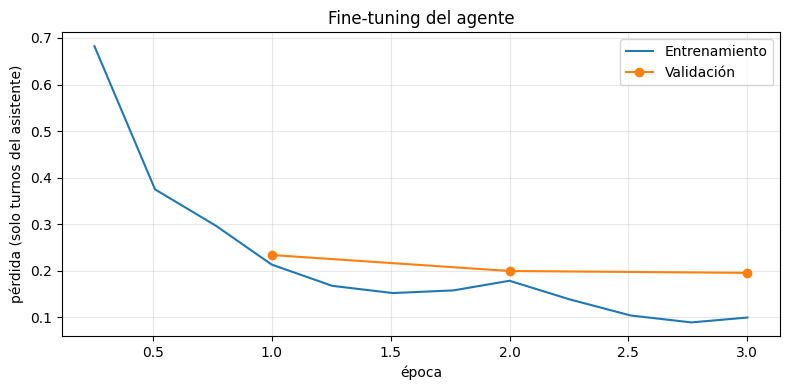

In [17]:
import matplotlib.pyplot as plt

log = pd.DataFrame(trainer.state.log_history)
fig, ax = plt.subplots(figsize=(8, 4))
tr = log.dropna(subset=["loss"])
ax.plot(tr["epoch"], tr["loss"], label="Entrenamiento")
ev = log.dropna(subset=["eval_loss"])
ax.plot(ev["epoch"], ev["eval_loss"], marker="o", label="Validación")
ax.set_xlabel("época"); ax.set_ylabel("pérdida (solo turnos del asistente)")
ax.set_title("Fine-tuning del agente"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 8 · Después de entrenar

In [18]:
modelo.eval()
modelo.config.use_cache = True
df_despues, res_despues = evaluar_decisiones(val_trs, "C5-FT (entrenado)")

comparacion = pd.DataFrame([res_antes, res_despues]).set_index("sistema")
print(comparacion.round(3).to_string())
print("\nPor tipo de trayectoria (decisión correcta):")
print(pd.DataFrame({"antes": df_antes.groupby("tipo")["decision"].mean(),
                    "después": df_despues.groupby("tipo")["decision"].mean()}).round(2).to_string())

                      n  decision  herramienta  llamada_valida  resultado
sistema                                                                  
base (sin entrenar)  42     0.143        0.025           0.075       0.05
C5-FT (entrenado)    42     0.952        0.875           1.000       0.65

Por tipo de trayectoria (decisión correcta):
                 antes  después
tipo                           
calculo           0.09      1.0
compuesto         0.00      1.0
documentos        0.00      1.0
error_dominio     0.00      1.0
mal_escrito       0.33      1.0
sin_herramienta   1.00      0.0


### De punta a punta, con el bucle real

La métrica anterior solo mira la **primera** decisión. Aquí se ejecuta el agente
completo (varios pasos, observaciones reales, verificador) sobre las trayectorias
de validación de cálculo, y se mira si la **respuesta final** es correcta.

In [19]:
def llm_actual(mensajes, esquemas):
    ids = tok(tok.apply_chat_template(mensajes, tools=esquemas, tokenize=False, add_generation_prompt=True),
              return_tensors="pt", add_special_tokens=False).to(modelo.device)
    with torch.no_grad():
        out = modelo.generate(**ids, max_new_tokens=256, do_sample=False,
                              pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id)
    return tok.decode(out[0][ids["input_ids"].shape[1]:], skip_special_tokens=True).strip()


def punta_a_punta(trs):
    aciertos = []
    for t in trs:
        agente = AgenteTutor(llm_actual, SYSTEM_C5_AGENTE, registro=REGISTRO, max_rondas=6, max_pasos=8, verificar=True)
        out = agente(t["pregunta"])
        aciertos.append(mismo_numero(valor_final(out.respuesta), t["valor"]))
    return float(np.mean(aciertos)) if aciertos else None


calc_val = [t for t in val_trs if t["valor"] and "buscar_documentos" not in t["herramientas"]]
with modelo.disable_adapter():
    e2e_antes = punta_a_punta(calc_val)
e2e_despues = punta_a_punta(calc_val)
print(f"Exactitud de punta a punta en {len(calc_val)} trayectorias de validación de cálculo:")
print(f"   base (sin entrenar): {e2e_antes:.1%}")
print(f"   C5-FT              : {e2e_despues:.1%}")

Exactitud de punta a punta en 36 trayectorias de validación de cálculo:
   base (sin entrenar): 86.1%
   C5-FT              : 88.9%


---
## 9 · Artefactos

In [20]:
DIR_ADAPTADOR = "adaptadores/qwen-lora-agente"
modelo.save_pretrained(DIR_ADAPTADOR)
tok.save_pretrained(DIR_ADAPTADOR)

Path("resultados").mkdir(exist_ok=True)
Path("resultados/finetuning_agente.json").write_text(json.dumps({
    "modelo_base": MODELO_BASE,
    "lora": {"r": config_lora.r, "alpha": config_lora.lora_alpha,
             "target_modules": sorted(config_lora.target_modules)},
    "entrenamiento": {"epocas": float(args.num_train_epochs), "lr": args.learning_rate,
                      "lote_efectivo": args.per_device_train_batch_size * args.gradient_accumulation_steps,
                      "n_train": len(ds_train), "n_val": len(ds_val),
                      "eval_loss_final": float(ev["eval_loss"].iloc[-1]) if len(ev) else None},
    "decisiones_validacion": {"antes": res_antes, "despues": res_despues},
    "punta_a_punta_validacion": {"n": len(calc_val), "antes": e2e_antes, "despues": e2e_despues},
}, ensure_ascii=False, indent=2, default=float), encoding="utf-8")
print("Guardado:", DIR_ADAPTADOR, "y resultados/finetuning_agente.json")
if USAR_WANDB:
    wandb.finish()

Guardado: adaptadores/qwen-lora-agente y resultados/finetuning_agente.json


eval/loss,█▂▁
eval/runtime,█▆▁
eval/samples_per_second,▁▁█
eval/steps_per_second,▁▁█
train/epoch,▁▂▂▃▃▄▄▅▅▅▆▇▇███
train/global_step,▁▂▂▃▃▄▄▅▅▅▆▇▇███
train/grad_norm,▆▅▄▇▃▁▄█▁▂▂▃
train/learning_rate,██▇▆▆▅▄▃▂▂▁▁
train/loss,█▄▃▂▂▂▂▂▂▁▁▁
eval/loss,0.19583
eval/runtime,78.9043


---
## 10 · Discusión

**1. ¿Qué aprendió?** Si `decision` y `llamada_valida` suben mucho y `resultado`
poco, el adaptador aprendió el **formato** de las llamadas pero no a **plantear**
los argumentos. Es el mismo patrón de M1 (formato antes que contenido), ahora con
herramientas.

**2. ¿Sobreajustó?** Hay 157 ejemplos de entrenamiento y el 80% sale del corpus de
M1, con muchas operaciones de un paso. Una pérdida de validación que sube desde la
segunda época, o un `decision` que empeora en `sin_herramienta`, son la señal de
que aprendió a llamar herramientas **siempre**.

**3. Esto no es la evaluación.** Las trayectorias de validación se parecen a las de
entrenamiento. El veredicto lo da el notebook 3, con el harness de M2 y el eval set
de M3, donde C5-FT se compara contra C5 en las mismas condiciones.

---
## 11 · Conclusiones de esta corrida

| Sobre 42 trayectorias de validación | Base | C5-FT |
|---|---|---|
| Decide bien si usar herramienta | 14.3% | **95.2%** |
| Elige la herramienta correcta | 2.5% | **87.5%** |
| La llamada es válida (JSON + tipos) | 7.5% | **100%** |
| El resultado coincide con el de la trayectoria | 5.0% | **65.0%** |
| Exactitud de punta a punta (36 casos de cálculo) | 86.1% | 88.9% |

**1 · Este es el hallazgo central de la entrega.** Con instrucciones y tres ejemplos,
un modelo de 1.5B decide bien cuándo usar una herramienta 1 de cada 7 veces.
Entrenado con 157 trayectorias, 19 de cada 20. El tool calling en modelos pequeños no
se consigue por prompting: se entrena.

**2 · El formato se aprende antes que el contenido.** Las llamadas válidas llegan al
100% y la elección de herramienta al 87.5%, pero el resultado correcto solo al 65%.
El adaptador aprendió a escribir la llamada mejor de lo que aprendió a plantear sus
argumentos: el mismo patrón que M1, donde el formato subió al 100% antes que la
exactitud.

**3 · La exactitud de punta a punta casi no se mueve** (86.1% → 88.9%), porque esas
trayectorias de validación son de cálculo sencillo y el modelo base ya las resolvía
de cabeza. La diferencia se ve en el notebook 3, sobre el bloque de aritmética
exigente, y sobre todo en **de dónde salen los números**: RAGAS mide que en C5-FT el
77% están respaldados por una fuente verificable, contra el 40–48% del resto.

**4 · Riesgo confirmado en el notebook 3: sobre-uso.** 151 de las 157 trayectorias de
entrenamiento contienen al menos una llamada, así que el adaptador aprendió a llamar
casi siempre. En el eval set se abstiene solo en el 20% de los casos donde no hacía
falta, y busca documentos menos que C5. Para una segunda versión habría que balancear
el dataset con más ejemplos de "aquí no se usa herramienta".

**5 · Sin señales de sobreajuste en la pérdida:** `eval_loss` final 0.196 con 3
épocas sobre 157 ejemplos, sin repunte entre épocas.